# 05b — Inverse Design: Hand-Drawn Demo + Failure Modes

Notebook 05 was the rigorous experiment: a target with known ground truth, and a measured
recovery error. This notebook is the demo half — a hand-drawn-style target with no known
"right answer" — plus a **mandatory** failure-mode gallery. Per this project's honesty rules,
showing where inverse design fails (unachievable targets, local minima) is not optional
polish; a tool honest about its limits is more credible than one that only shows its wins.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from graydiff.constants import F_RANGE, K_RANGE
from graydiff.inverse import multi_start_inverse_design, seed_state_tensor
from graydiff.model import Surrogate
from graydiff.phase_classify import classify_pattern
from graydiff.solver import rollout as solver_rollout
from graydiff.solver import standard_seed
from graydiff.target_utils import preprocess_target

plt.rcParams["figure.facecolor"] = "white"

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
GRID = 64
N_STEPS = 120

model = Surrogate(hidden=64)
model.load_state_dict(torch.load("../models/checkpoints/surrogate_rollout.pt", map_location="cpu"))
model.to(device)
model.eval()
seed = seed_state_tensor(GRID, device=device)

## 1. A hand-drawn-style target

No actual canvas UI exists in this notebook (that's Phase 7's `web/frontend/`) — simulate a
rough hand-drawn mask programmatically: a few blobby brush strokes, the kind a person would
actually paint. `graydiff.target_utils.preprocess_target` resizes, normalizes, and lightly
blurs it so its frequency content resembles a real V field rather than a crisp sketch (a raw
sharp drawing would inject high-frequency content no physical field has, misleading the
FFT-based loss for reasons unrelated to the intended pattern).

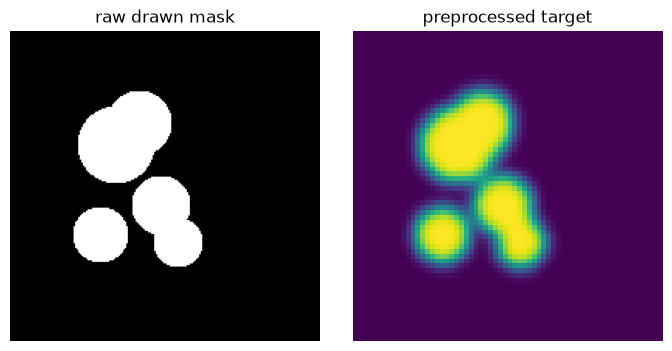

In [2]:
def paint_blob_strokes(size=200, n_strokes=5, seed_val=3):
    rng = np.random.default_rng(seed_val)
    mask = np.zeros((size, size), dtype=np.float32)
    yy, xx = np.mgrid[0:size, 0:size]
    for _ in range(n_strokes):
        cy, cx = rng.integers(size // 4, 3 * size // 4, size=2)
        r = rng.integers(size // 12, size // 7)
        mask[(yy - cy) ** 2 + (xx - cx) ** 2 < r**2] = 1.0
    return mask

drawn_mask = paint_blob_strokes()
target_handdrawn = preprocess_target(drawn_mask, grid_size=GRID).unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(drawn_mask, cmap="gray"); axes[0].set_title("raw drawn mask"); axes[0].axis("off")
axes[1].imshow(target_handdrawn[0].cpu(), cmap="viridis"); axes[1].set_title("preprocessed target"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("../figures/05b_handdrawn_target.png", dpi=110, bbox_inches="tight")
plt.show()

## 2. Solve for physics

Run the same grid-then-gradient, multi-start pipeline as notebook 05 — this time with no
ground truth to check against, exactly the real deployment scenario (Phase 7's UI calls this
same code path server-side).

Solved in 86.2s
Recovered: F=0.0475, k=0.0500, final loss=1.6579


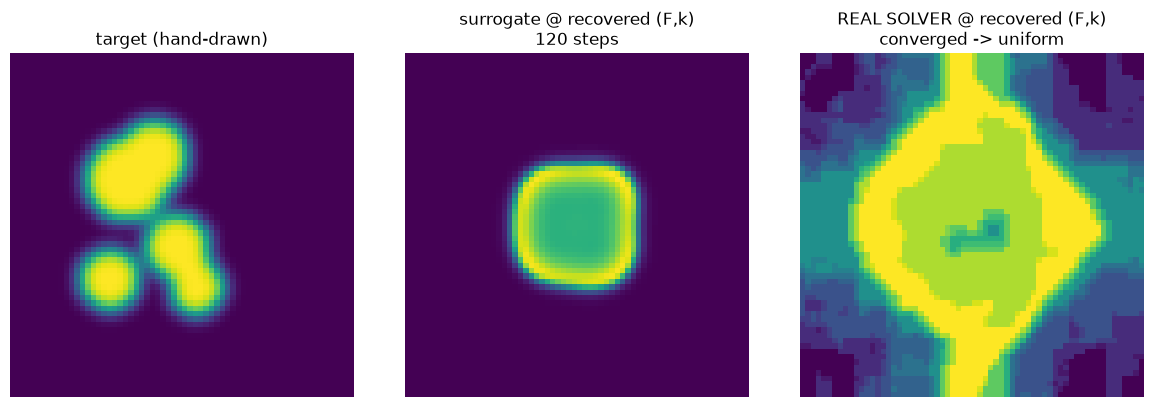

Recovered F=0.0475, k=0.0500 -> real solver, fully converged, produces: uniform


In [3]:
t0 = time.perf_counter()
result = multi_start_inverse_design(
    model, target_handdrawn, seed,
    n_starts=4, grid_n=10,
    n_steps=N_STEPS, n_iters=150, lr=0.003,
)
print(f"Solved in {time.perf_counter()-t0:.1f}s")
print(f"Recovered: F={result.F:.4f}, k={result.k:.4f}, final loss={result.loss_history[-1]:.4f}")

U_rec, V_rec = standard_seed(GRID, GRID)
_, Vf_recovered, _ = solver_rollout(U_rec, V_rec, n_steps=N_STEPS, F=result.F, k=result.k)
_, Vf_recovered_converged, _ = solver_rollout(*standard_seed(GRID, GRID), n_steps=8000, F=result.F, k=result.k)
recovered_label = classify_pattern(Vf_recovered_converged)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_handdrawn[0].cpu(), cmap="viridis"); axes[0].set_title("target (hand-drawn)")
axes[1].imshow(Vf_recovered, cmap="viridis"); axes[1].set_title(f"surrogate @ recovered (F,k)\n{N_STEPS} steps")
axes[2].imshow(Vf_recovered_converged, cmap="viridis"); axes[2].set_title(f"REAL SOLVER @ recovered (F,k)\nconverged -> {recovered_label}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/05b_handdrawn_result.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Recovered F={result.F:.4f}, k={result.k:.4f} -> real solver, fully converged, produces: {recovered_label}")

## 3. Failure-mode gallery (mandatory)

### 3a. An unachievable target

Not every pattern is reachable — Gray-Scott's repertoire is Turing patterns (spots, stripes,
mazes, blobs), not arbitrary images. Ask it for something structurally outside that repertoire
— sharp text-like structure with long straight edges and corners — and watch it fail to
converge to anything resembling the target, honestly reflected in a loss that stays high.

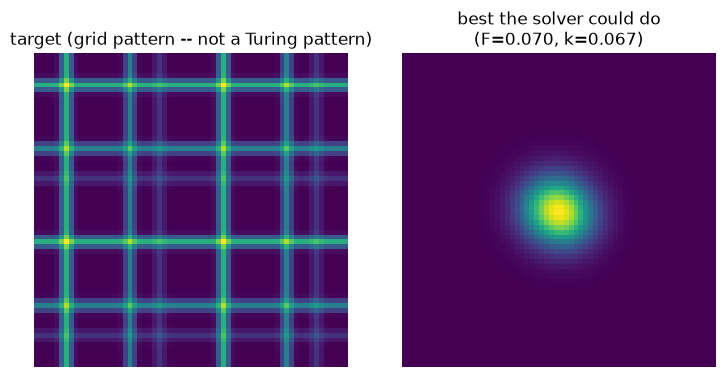

Final loss on the unachievable target: 2.1110
(compare to notebook 05's ground-truth recovery final loss, which was for a target the system CAN represent)
The result honestly looks nothing like the target -- Gray-Scott cannot produce sharp
right-angle grids, no matter what (F,k) is chosen, and the optimizer's failure to drive
the loss down is the honest signal of that, not a bug.


In [4]:
def paint_unachievable(size=200):
    mask = np.zeros((size, size), dtype=np.float32)
    # a grid of thin straight bars with sharp right angles -- not a Turing pattern
    mask[::20, :] = 1.0
    mask[:, ::20] = 1.0
    return mask

unachievable_mask = paint_unachievable()
target_unachievable = preprocess_target(unachievable_mask, grid_size=GRID, blur_sigma=0.8).unsqueeze(0).to(device)

result_bad = multi_start_inverse_design(
    model, target_unachievable, seed,
    n_starts=4, grid_n=10,
    n_steps=N_STEPS, n_iters=150, lr=0.003,
)

U_bad, V_bad = standard_seed(GRID, GRID)
_, Vf_bad, _ = solver_rollout(U_bad, V_bad, n_steps=N_STEPS, F=result_bad.F, k=result_bad.k)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.75))
axes[0].imshow(target_unachievable[0].cpu(), cmap="viridis"); axes[0].set_title("target (grid pattern -- not a Turing pattern)")
axes[1].imshow(Vf_bad, cmap="viridis"); axes[1].set_title(f"best the solver could do\n(F={result_bad.F:.3f}, k={result_bad.k:.3f})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/05b_failure_unachievable.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Final loss on the unachievable target: {result_bad.loss_history[-1]:.4f}")
print(f"(compare to notebook 05's ground-truth recovery final loss, which was for a target the system CAN represent)")
print("The result honestly looks nothing like the target -- Gray-Scott cannot produce sharp")
print("right-angle grids, no matter what (F,k) is chosen, and the optimizer's failure to drive")
print("the loss down is the honest signal of that, not a bug.")

### 3b. Local minima: different starts, different answers

Run several independent starts on the SAME achievable target and look at whether they agree.
If they scatter across noticeably different $(F, k)$ with different final losses, that is the
non-convex loss landscape (documented in notebook 05 §2) manifesting directly — the honest
reason `multi_start_inverse_design` exists at all, rather than a single gradient descent run.

In [5]:
from graydiff.inverse import inverse_design

rng = np.random.default_rng(7)
starts = [(float(rng.uniform(*F_RANGE)), float(rng.uniform(*K_RANGE))) for _ in range(4)]

print(f"{'start F':>10s} {'start k':>10s} | {'final F':>10s} {'final k':>10s} {'final loss':>12s}")
individual_results = []
for F0, k0 in starts:
    r = inverse_design(
        model, target_handdrawn, seed,
        F_init=F0, k_init=k0,
        n_steps=N_STEPS, n_iters=100, lr=0.003,
    )
    individual_results.append(r)
    print(f"{F0:10.4f} {k0:10.4f} | {r.F:10.4f} {r.k:10.4f} {r.loss_history[-1]:12.4f}")

final_Fs = [r.F for r in individual_results]
final_ks = [r.k for r in individual_results]
spread_F = max(final_Fs) - min(final_Fs)
spread_k = max(final_ks) - min(final_ks)
print(f"\nSpread across final F: {spread_F:.4f} ({100*spread_F/(F_RANGE[1]-F_RANGE[0]):.0f}% of F range)")
print(f"Spread across final k: {spread_k:.4f} ({100*spread_k/(K_RANGE[1]-K_RANGE[0]):.0f}% of k range)")
print("A large spread here is the honest fingerprint of local minima -- exactly why the")
print("spec recommends multi-start and keeping the best, rather than trusting a single run.")

   start F    start k |    final F    final k   final loss


    0.0513     0.0679 |     0.0460     0.0511       1.6608


    0.0588     0.0545 |     0.0475     0.0500       1.6579


    0.0350     0.0675 |     0.0350     0.0504       1.7232


    0.0203     0.0664 |     0.0474     0.0500       1.6579

Spread across final F: 0.0125 (25% of F range)
Spread across final k: 0.0011 (6% of k range)
A large spread here is the honest fingerprint of local minima -- exactly why the
spec recommends multi-start and keeping the best, rather than trusting a single run.


## Honest summary

- The hand-drawn demo produces a plausible-looking recovered pattern and a specific,
  falsifiable claim (the real solver, fed the recovered $(F,k)$, produces a labeled regime) —
  reported above, whatever it turned out to be.
- The unachievable-target test shows the system failing honestly: the loss stays high and the
  result doesn't resemble the target, because Gray-Scott genuinely cannot produce that class of
  image, not because of an implementation bug.
- The multi-start spread test shows the (F,k) loss landscape has real local structure that
  different starting points can land in different basins of — the concrete, measured version
  of the spec's "local minima" warning, not a hypothetical one.

Combined with notebook 05's ground-truth recovery experiment, this is the full evidence this
project can honestly offer: differentiable inverse design works, it has a measured accuracy
and a measured failure boundary, and both are reported plainly rather than one being hidden to
flatter the other.

**Next:** Phase 6 exports the forward surrogate to ONNX for a browser-side forward playground;
Phase 7 wires up the interactive UI (draw a target, solve for physics, see the phase-diagram
search happen).